# 11 — ONNX Export & Post-Export Quantization

Export the best pruned model (pruning ratio=0.4, fine-tuned) to ONNX format, then apply ONNX Runtime static quantization (int8) using a custom `BrainCalibrationReader` defined in `src/deployment.py`.

**Pipeline:**
1. Load pruned+fine-tuned PyTorch model
2. Export to ONNX via `torch.onnx.export` (dynamo exporter)
3. Validate ONNX graph and run inference with `onnxruntime`
4. Apply static int8 quantization with `onnxruntime.quantization.quantize_static`
5. Measure size, latency and KL score at each stage

**Visualisations:**
- Before export vs after int8 quantization (normalized to pre-export baseline)
- Full 5-stage optimization pipeline: raw model → pruned → pruned+fine-tuned → ONNX export → ONNX int8, with all metrics normalized to the raw model baseline

In [11]:
import numpy as np
import pandas as pd

import torch
import torch_pruning as tp
import onnx
import onnxruntime as ort

from src.dataset import *
from src.lightning import *
from src.models import *
from src.params import *
from src.utils import *
from src.deployment import *




# Generating pruned model 

In [ ]:
PRUNING_RATIO = 0.4

files_dir = PROCESSED_DIR / "cropped" / "files"
metadata = pd.read_csv(DATA_DIR / "train.csv")
dm = BrainDataModule(metadata=metadata, spec_dir= files_dir, batch_size= 32, num_workers= 8, verbose= False)

#generate dataloaders
dm.setup()

#get model from lit_model with best model architecture and hyperparams 
model = instantiate_model(BEST_WEIGHTS_PATH)

#prepare pruning
dummy_input = torch.randn(1,4,100,25)
imp = tp.importance.MagnitudeImportance(p= 2)
ignored_layers = get_ignored_layers(model)

pruner = tp.pruner.MagnitudePruner(model= model, example_inputs= dummy_input,
                                importance = imp,
                                pruning_ratio = PRUNING_RATIO,
                                ignored_layers= ignored_layers)

#prune in place
pruner.step()

#load fine tuned weights
ckpt_list = list((CHECKPOINTS_DIR / f"pruning_{PRUNING_RATIO}").glob("*ckpt"))
lit_model = BrainLightning.load_from_checkpoint(ckpt_list[0], model = model)


[setup] Loading splits from cache: /Users/pablorougerie/code/Projets/brain_waves/data/cache/5_at_seed_273_min_vote_1.json
[setup] Cache loaded — 5 folds found


In [3]:
sizes = []
latencies = []
perfs = []
stages = []

size_before, latency_before, score_before = model_efficience_report(model= lit_model.model, datamodule= dm)
sizes.append(size_before)
latencies.append(latency_before)
perfs.append(score_before)
stages.append("before_export")


load model
calculate size and latency
calculate model inference score

-----------------------------------
  Model Efficiency Report
-----------------------------------
  Total params:        438,230
  Trainable params:    438,230
  Model size (MB):     1.675
-----------------------------------
  Median latency (ms): 3.07
  Max latency (ms):    15.91
-----------------------------------
  KL score: 0.6852
-----------------------------------



# ONNX export

## Export

In [4]:
model_to_export = lit_model.model.cpu().float().eval()
dummy_input =   torch.randn(1,4,100,25)
export_dir = (CHECKPOINTS_DIR / "export")
export_dir.mkdir(parents= True, exist_ok= True)
onnx_path  = export_dir /"model_brain_pruned040.onnx"
onnx_path_quantized = export_dir /"model_brain_pruned040_int8.onnx"
#export
torch.onnx.export(
    model_to_export,
    dummy_input,
    str(onnx_path),
    export_params= True,
    opset_version = 17,
    do_constant_folding= True,
    input_names= ["spectrogram"],
    output_names = ["class_logits"],
    dynamic_axes = {
        "spectrogram": {0: "batch_size"},
        "class_logits": {0: "batch_size"}
    }
)

#check model
model_onnx = onnx.load(str(onnx_path))
onnx.checker.check_model(model_onnx)
print("ONNX model valid")

/var/folders/dk/v6_xfc950bb08vyf1lm9v0x00000gn/T/ipykernel_12174/1879890119.py:8: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0417 18:07:32.066000 12174 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `OptunaModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `OptunaModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/Users/pablorougerie/.pyenv/versions/3.12.9/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/pablorougerie/code/Projets/brain_waves/.venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/pablorougerie/code/Projets/brain_waves/.venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
         

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 13 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model valid


## measure characteristics before quantization

In [5]:
# create session 
session = ort.InferenceSession(
    path_or_bytes= str(onnx_path),
    providers = ["CPUExecutionProvider"]
)

size, latency, score = onnx_model_efficience_report(path = onnx_path, session = session, datamodule = dm)
sizes.append(size)
latencies.append(latency)
perfs.append(score)
stages.append("after_export")


-----------------------------------
  Model Efficiency Report ONNX
-----------------------------------
  Model size (MB):     2.174
-----------------------------------
  Median latency (ms): 2.90
  Max latency (ms):    14.02
-----------------------------------
  KL score: 0.6852
-----------------------------------



# ONNX quantization

In [7]:
reader = BrainCalibrationReader(datamodule = dm)
quantize_static(str(onnx_path), str(onnx_path_quantized), reader)

In [8]:
# create session 
session = ort.InferenceSession(
    path_or_bytes= str(onnx_path_quantized),
    providers = ["CPUExecutionProvider"]
)

size, latency, score = onnx_model_efficience_report(path = onnx_path_quantized, session = session, datamodule = dm)
sizes.append(size)
latencies.append(latency)
perfs.append(score)
stages.append("after_quantization")


-----------------------------------
  Model Efficiency Report ONNX
-----------------------------------
  Model size (MB):     0.460
-----------------------------------
  Median latency (ms): 0.40
  Max latency (ms):    5.22
-----------------------------------
  KL score: 0.6868
-----------------------------------



In [9]:
result_df = pd.DataFrame({
    "stage": stages,
    "size_mb": sizes,
    "latency_ms": latencies,
    "kl_score": perfs
})

In [10]:
result_df

,stage,size_mb,latency_ms,kl_score
0,before_export,1.674950,3.065792,0.685242
1,after_export,2.173515,2.901375,0.685242
2,after_quantization,0.460213,0.403959,0.686817


In [15]:
result_df.to_csv(DATA_DIR / "export_results.csv", index= False)

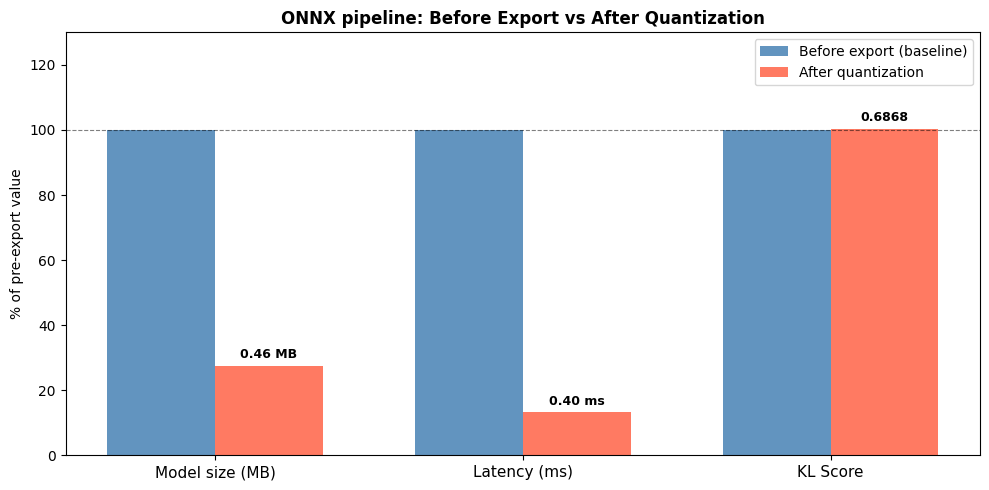

In [16]:
import matplotlib.pyplot as plt
import numpy as np

result_df = pd.read_csv(DATA_DIR / "export_results.csv")  # reload if needed

baseline = result_df[result_df["stage"] == "before_export"].iloc[0]
final    = result_df[result_df["stage"] == "after_quantization"].iloc[0]

metrics = [
    ("size_mb",    "Model size (MB)",  "{:.2f} MB"),
    ("latency_ms", "Latency (ms)",     "{:.2f} ms"),
    ("kl_score",   "KL Score",         "{:.4f}"),
]

labels     = ["Before export", "After quantization"]
x          = np.arange(len(metrics))
width      = 0.35
colors     = {"before": "#8C8C8C", "after": "#4C72B0"}

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width / 2, [100, 100, 100], width, label="Before export (baseline)", color=colors["before"], alpha=0.85)

after_pcts = [final[col] / baseline[col] * 100 for col, _, _ in metrics]
bars_after = ax.bar(x + width / 2, after_pcts, width, label="After quantization", color=colors["after"], alpha=0.85)

for bar, (col, _, fmt) in zip(bars_after, metrics):
    ax.text(
        bar.get_x() + bar.get_width() / 2 + 0.0,
        bar.get_height() + 1.5,
        fmt.format(final[col]),
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels([title for _, title, _ in metrics], fontsize=11)
ax.set_ylabel("% of pre-export value")
ax.set_title("ONNX pipeline: Before Export vs After Quantization", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, 130)
plt.tight_layout()
plt.show()


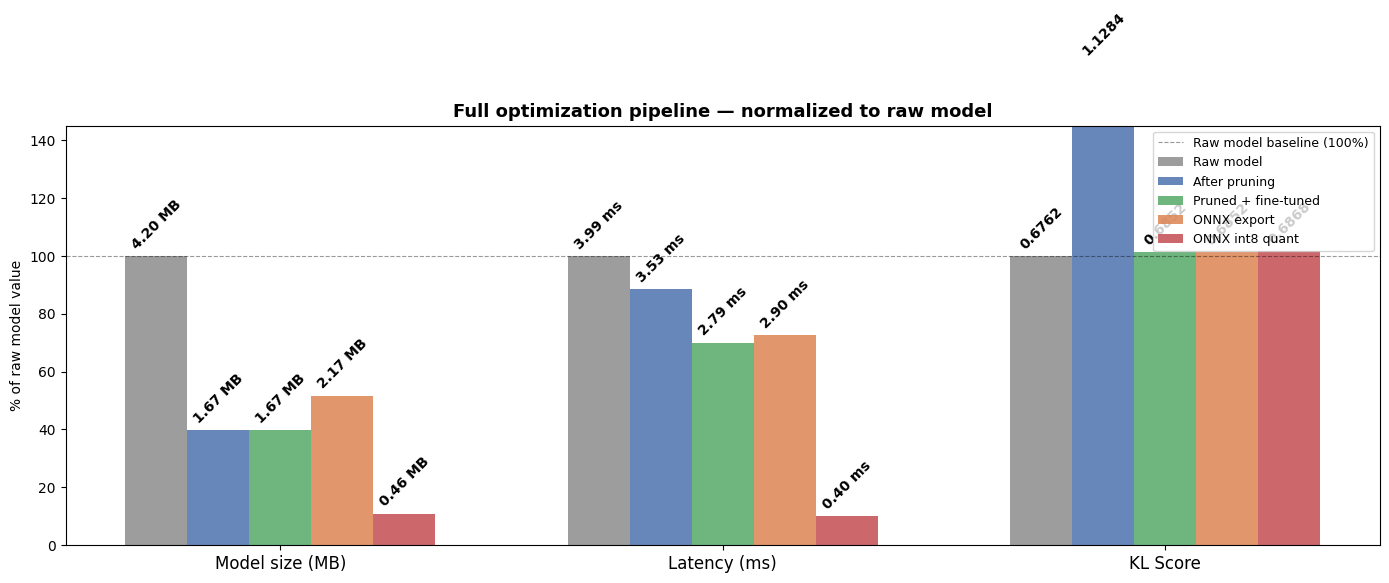

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# --- load data ---
pr_df  = pd.read_csv(DATA_DIR / "pruning_results.csv")
raw    = pr_df[pr_df["pruning_ratio"] == 0.0].iloc[0]
pruned = pr_df[pr_df["pruning_ratio"] == 0.4].iloc[0]

onnx_export = result_df[result_df["stage"] == "after_export"].iloc[0]
onnx_quant  = result_df[result_df["stage"] == "after_quantization"].iloc[0]

# --- 5-stage pipeline ---
pipeline = [
    (raw["sizes"],           raw["latency"],           raw["score"],           "Raw model"),
    (pruned["sizes"],        pruned["latency"],         pruned["score"],        "After pruning"),
    (pruned["sizes_tuned"],  pruned["latency_tuned"],   pruned["score_tuned"],  "Pruned + fine-tuned"),
    (onnx_export["size_mb"], onnx_export["latency_ms"], onnx_export["kl_score"], "ONNX export"),
    (onnx_quant["size_mb"],  onnx_quant["latency_ms"],  onnx_quant["kl_score"],  "ONNX int8 quant"),
]

stage_labels = [p[3] for p in pipeline]
sizes  = [p[0] for p in pipeline]
lats   = [p[1] for p in pipeline]
scores = [p[2] for p in pipeline]

# normalize to raw model = 100%
size_pct  = [v / sizes[0]  * 100 for v in sizes]
lat_pct   = [v / lats[0]   * 100 for v in lats]
score_pct = [v / scores[0] * 100 for v in scores]

metrics = [
    (size_pct,  sizes,  "Model size (MB)", "{:.2f} MB"),
    (lat_pct,   lats,   "Latency (ms)",    "{:.2f} ms"),
    (score_pct, scores, "KL Score",        "{:.4f}"),
]

n       = len(pipeline)
x       = np.arange(3)
width   = 0.14
offsets = np.linspace(-(n - 1) / 2 * width, (n - 1) / 2 * width, n)
colors  = ["#8C8C8C", "#4C72B0", "#55A868", "#DD8452", "#C44E52"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, (label, color) in enumerate(zip(stage_labels, colors)):
    group_vals = [pct[i] for pct, _, _, _ in metrics]
    bars = ax.bar(x + offsets[i], group_vals, width, label=label, color=color, alpha=0.85)
    for bar, (_, abs_vals, _, fmt) in zip(bars, metrics):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            fmt.format(abs_vals[i]),
            ha="center", va="bottom", fontsize=10, fontweight="bold", rotation=45
        )

ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.4, label="Raw model baseline (100%)")
ax.set_xticks(x)
ax.set_xticklabels([title for _, _, title, _ in metrics], fontsize=12)
ax.set_ylabel("% of raw model value")
ax.set_title("Full optimization pipeline — normalized to raw model", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.set_ylim(0, 145)
plt.tight_layout()
plt.show()
